In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\kenya.csv")

# Add country column
df["Country"] = "Kenya"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [4]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

In [5]:
df.replace(-999, np.nan, inplace=True)

In [6]:
df.duplicated().sum()

0

In [7]:
df = df.drop_duplicates()

### Duplicate Data Check

The dataset was checked for duplicate rows using `df.duplicated().sum()`.  
Any duplicates found were removed to ensure data integrity and avoid biased analysis results.

Removing duplicates helps maintain the accuracy of statistical summaries and visualizations.

In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Summary Statistics Interpretation

The summary statistics provide an overview of the dataset's distribution.

- Temperature (T2M) shows the general climate pattern, with values indicating moderate variation.
- Maximum and minimum temperatures help understand daily extremes.
- Precipitation (PRECTOTCORR) shows variability, indicating seasonal rainfall patterns.
- Wind speed and humidity values indicate atmospheric conditions.

Overall, the dataset reflects typical climate variability across time.

In [9]:
missing = df.isna().sum()
percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing": missing,
    "Percent": percent
})

,Missing,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Values Analysis

Missing values were identified and calculated as percentages per column.

Columns with more than 5% missing values may affect the reliability of the analysis.  
These missing values could be due to sensor errors or unavailable satellite data.

Handling missing values is essential to ensure accurate modeling and visualization.

In [10]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
outliers

124

### Outlier Detection

Outliers were detected using Z-scores for key climate variables such as temperature, rainfall, humidity, and wind speed.

Rows with a Z-score greater than 3 were flagged as potential outliers.

Outliers may represent extreme weather events or measurement errors.  
In this analysis, they were retained to preserve important climate variability, unless they were clearly erroneous.

In [11]:
# Drop rows with >30% missing
df = df[df.isna().mean(axis=1) < 0.3]

# Forward fill
df.fillna(method="ffill", inplace=True)

C:\Users\yordi\AppData\Local\Temp\ipykernel_80484\660774383.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [12]:
df.to_csv("C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\kenya_clean.csv", index=False)

### Data Cleaning Strategy

Rows with more than 30% missing values were removed to maintain data quality.

For remaining missing values, forward-fill was applied to preserve temporal continuity in the dataset.

This approach ensures minimal data loss while maintaining consistency for time series analysis.

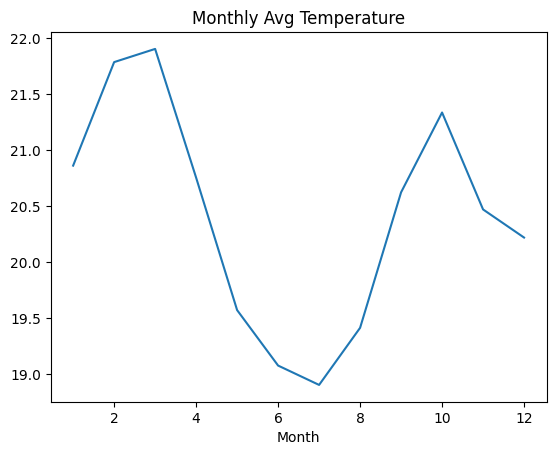

In [13]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Avg Temperature")
plt.show()

### Monthly Temperature Analysis

The monthly average temperature shows seasonal variation across the year.

- Warmer months can be identified by peaks in the graph.
- Cooler months correspond to lower values.

This helps understand climate seasonality and long-term temperature patterns.

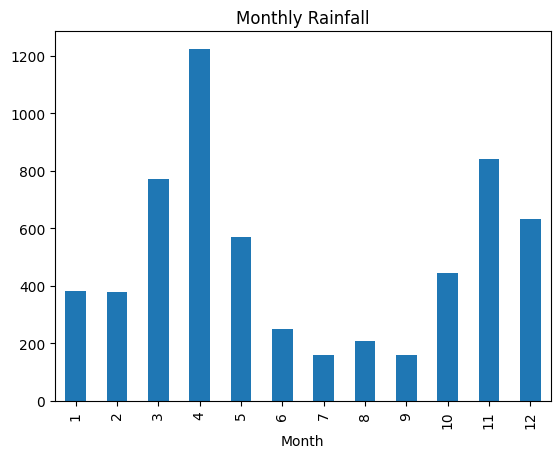

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

### Monthly Rainfall Analysis

The bar chart shows total monthly precipitation.

- Peak rainfall months indicate the rainy season.
- Low rainfall months represent dry periods.

This pattern is useful for understanding agricultural cycles and water resource planning.

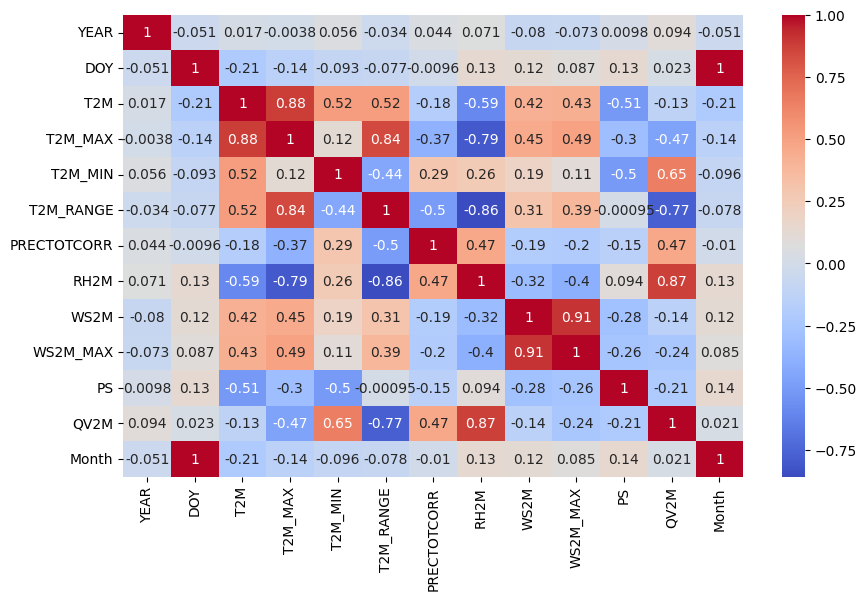

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Correlation Analysis

The heatmap shows relationships between numerical variables.

Strong correlations indicate dependencies between variables such as:
- Temperature and humidity
- Wind speed relationships

Understanding these correlations helps identify key climate drivers.

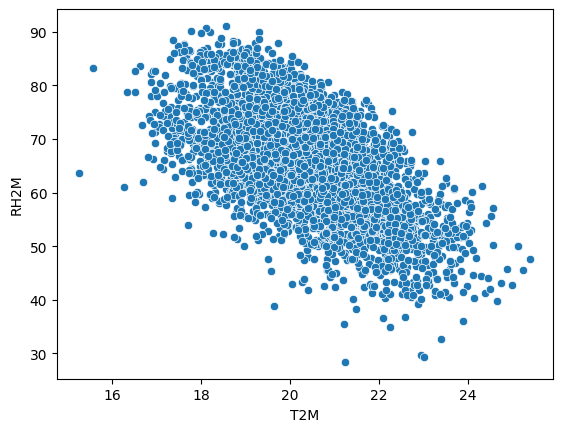

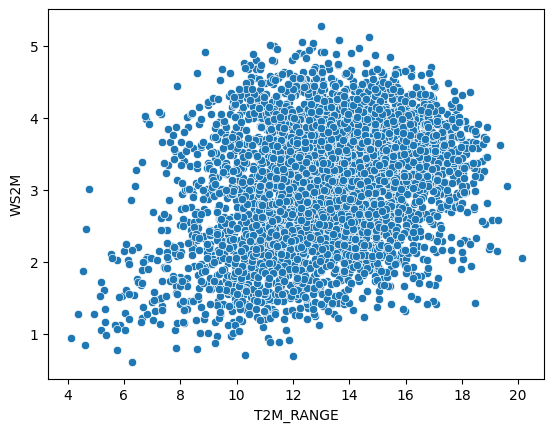

In [16]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

### Relationship Between Variables

Scatter plots reveal relationships between:

- Temperature (T2M) and humidity (RH2M)
- Temperature range and wind speed

These plots help visualize patterns and potential dependencies between climate variables.

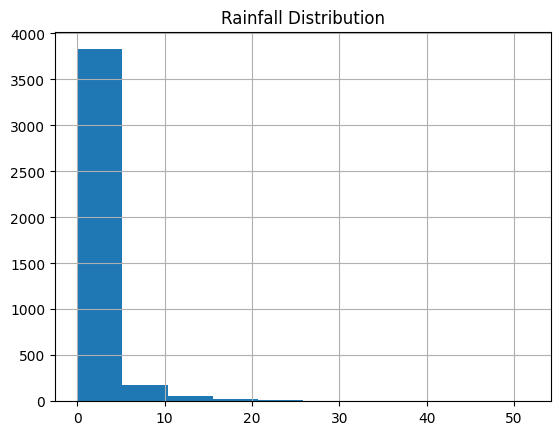

In [17]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

<Axes: >

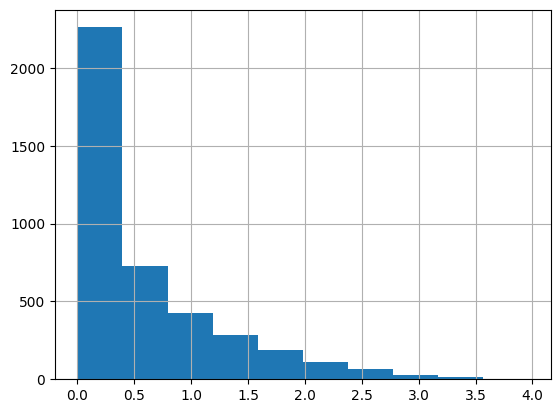

In [18]:
np.log1p(df["PRECTOTCORR"]).hist()

### Rainfall Distribution

The histogram shows the distribution of precipitation values.

The data appears skewed, indicating that most days have low rainfall, with occasional heavy rain events.

A log transformation was applied to better visualize the distribution.

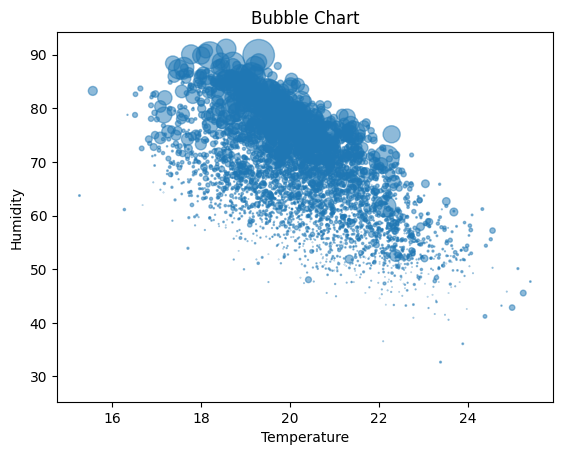

In [19]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()

### Key Insights

- The dataset shows clear seasonal climate patterns.
- Temperature varies moderately throughout the year.
- Rainfall is concentrated in specific months, indicating distinct wet and dry seasons.
- Some variables show strong correlations, suggesting interdependence in climate systems.
- Outliers may represent extreme weather conditions, which are important for climate analysis.

These insights are valuable for understanding climate trends in Ethiopia ahead of COP32 discussions.